<img src="./logo_UNSAM.jpg" align="right" width="150" />
<h4><font color='#1F4E79'><b>Análisis y Procesamiento de Señales</b></font></h4>
# <font color='#2E75B6'>Trabajo Práctico Nº0: Hola Mundo versión APS</font>
#### **Alumna:** Paloma Ribnikar Diaz
#### **Universidad Nacional de San Martín (UNSAM)**
<hr style="border: 1px solid #2E75B6;">


# Introducción

Jupyter Notebook es una herramienta para la confección de reportes técnicos, dado que permite la interacción en el mismo ambiente de:

* **Editor de texto** con formato Markdown
* Posibilidad de incorporar **lenguaje matemático** vía LaTeX
* Posibilidad de incluir **código y (re)generación automática** de gráficas y tablas
* Posibilidad de **insertar contenidos multimedia**


In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
@author: Paloma Ribnikar Diaz
Descripción: Testbench de generación de señales (Senoidales y Ruido Blanco Gaussiano)
"""

import numpy as np
import matplotlib.pyplot as plt

def my_testbench(sig_type):
    fs = 1000.0 # Frecuencia de muestreo (Hz)
    N = 1000    # Cantidad de muestras
    ts = 1/fs   # Tiempo de muestreo
    df = fs/N   # Resolución espectral
    
    tt = np.linspace(0, (N-1)*ts, N).flatten()
    x = np.array([], dtype=float).reshape(N,0)
    ii = 0
    
    if sig_type['tipo'] == 'senoidal':
        for this_freq in sig_type['frecuencia']:
            aux = sig_type['amplitud'][ii] * np.sin(2*np.pi*this_freq*tt + sig_type['fase'][ii])
            x = np.hstack([x, aux.reshape(N,1)])
            ii += 1
    elif sig_type['tipo'] == 'ruido':
        for this_var in sig_type['varianza']:
            aux = np.sqrt(this_var) * np.random.randn(N,1)
            x = np.hstack([x, aux])
        sig_type['descripcion'] = [sig_type['descripcion'][i] + ' - $\hat{{\sigma}}^2$ :{0:.3f}'.format(np.var(x[:,i])) for i in range(len(sig_type['descripcion']))]
    else:
        print('Tipo de señal no implementado.')
        return
        
    plt.figure(figsize=(10, 4))
    line_hdls = plt.plot(tt, x)
    plt.title('Señal: ' + sig_type['tipo'], fontsize=12, color='#1F4E79')
    plt.xlabel('Tiempo [segundos]')
    plt.ylabel('Amplitud [V]')
    plt.grid(True)
    plt.legend(line_hdls, sig_type['descripcion'], loc='upper right')
    plt.tight_layout()
    plt.show()


## 🛠️ Modificación de Parámetros y Evaluación Práctica

A partir de la función `my_testbench()` definida arriba, procederemos a instanciar distintas señales modificando sus parámetros característicos (frecuencias, amplitudes, fases y varianzas de ruido).

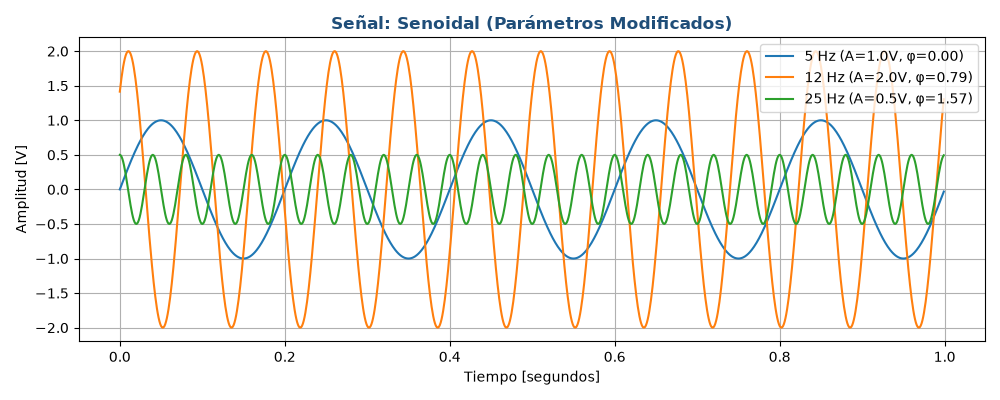

In [2]:
# Caso 1: Senoidales con parámetros modificados
sig_props = {
    'tipo': 'senoidal',
    'frecuencia': (5, 12, 25),      # Frecuencias modificadas a 5 Hz, 12 Hz y 25 Hz
    'amplitud':   (1.0, 2.0, 0.5),   # Amplitudes modificadas a 1.0 V, 2.0 V y 0.5 V
    'fase':       (0, np.pi/4, np.pi/2) # Fases desfasadas a 0, pi/4 y pi/2 rad
}
sig_props['descripcion'] = [f"{f} Hz (A={a}V, φ={p:.2f})" for f, a, p in zip(sig_props['frecuencia'], sig_props['amplitud'], sig_props['fase'])]

my_testbench(sig_props)


### 🎲 Señal Aleatoria (Ruido Blanco Gaussiano)

Modificamos ahora las varianzas del ruido blanco Gaussiano a $\sigma^2 = (0.5, 1.5, 3.0)$ para observar la diferencia en la dispersión de la amplitud y comparar la varianza teórica $\sigma^2$ con la varianza estimada $\hat{\sigma}^2$ calculada a partir de las muestras:

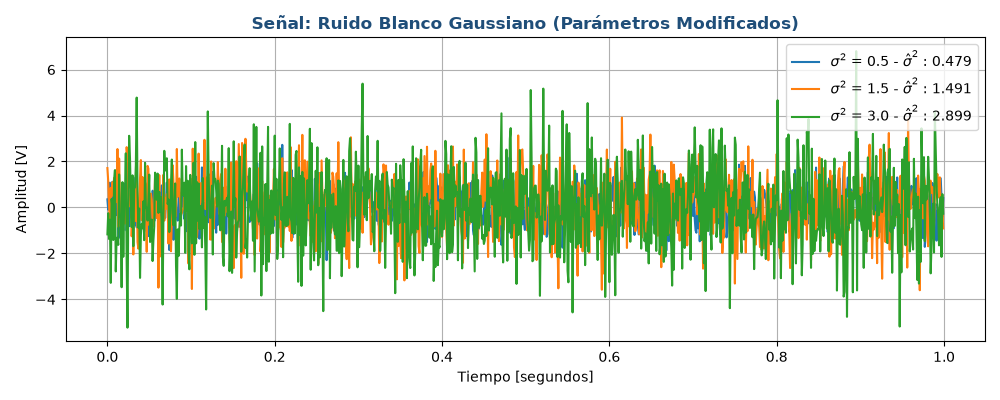

In [3]:
# Caso 2: Ruido Blanco Gaussiano con varianzas modificadas
sig_props = {
    'tipo': 'ruido',
    'varianza': (0.5, 1.5, 3.0) # Varianzas modificadas a 0.5, 1.5 y 3.0
}
sig_props['descripcion'] = ['$\sigma^2$ = ' + str(a_var) for a_var in sig_props['varianza']]

my_testbench(sig_props)


## 📝 Presentación y Resumen del Trabajo ("Hola Mundo")

#### **1. Presentación Personal**
Mi nombre es **Paloma Ribnikar Diaz**, estudiante de la carrera de Ingeniería en la **Universidad Nacional de San Martín (UNSAM)**. Este trabajo corresponde a los primeros pasos de configuración del entorno de desarrollo para la materia *Análisis y Procesamiento de Señales*.

#### **2. Preparación del Entorno de Trabajo**
Durante esta primera semana completé la instalación y configuración del kit de herramientas solicitado:
* **Python 3.10+** y gestor de paquetes `pip`.
* **Spyder IDE** como entorno de desarrollo científico.
* **Jupyter Notebook** para la confección interactiva de reportes técnicos.
* **Git y GitHub** para la gestión del repositorio personal de entregas (`pdstestbench`).

#### **3. Modificaciones Realizadas en la Plantilla**
* **Encabezado y formato:** Personalicé la plantilla institucional añadiendo el logo oficial de la UNSAM, mi nombre y formateando títulos con sintaxis HTML y Markdown.
* **Señal Senoidal:** Modifiqué la tupla de parámetros para generar tres componentes de frecuencias $f = (5, 12, 25)\text{ Hz}$, amplitudes $A = (1.0, 2.0, 0.5)\text{ V}$ y desfasajes iniciales $\phi = (0, \pi/4, \pi/2)\text{ rad}$.
* **Ruido Blanco Gaussiano:** Alteré las varianzas teóricas a $\sigma^2 = (0.5, 1.5, 3.0)$, observando cómo varía la amplitud del ruido y verificando la diferencia (sesgo) entre la varianza teórica y la estimación $\hat{\sigma}^2$.

#### **4. Conclusión**
Con la realización de este "Hola Mundo" afiancé la dinámica de trabajo para la materia: el flujo entre la programación del testbench, la generación de gráficos en Python y la publicación del reporte proyectado online mediante **GitHub** y **nbviewer.org**.
